In [30]:
import pandas as pd

df = pd.read_csv("user_journey_funnel.csv")


In [31]:

df.head()


,User_ID,Session_ID,Event,Time_Stamp,Device,Region,Channel,Category,Revenue,Bounce_back
0,USR00001,SES00001,Browse,2026-06-01 02:32:19,mobile,North,Organic Search,Fashion,NaN,False
1,USR00001,SES00001,Add to Cart,2026-06-01 02:33:19,mobile,North,Organic Search,Fashion,NaN,False
2,USR00001,SES00001,Checkout,2026-06-01 02:41:19,mobile,North,Organic Search,Fashion,NaN,False
3,USR00001,SES00001,Purchase,2026-06-01 02:48:19,mobile,North,Organic Search,Fashion,128.53,False
4,USR00002,SES00002,Browse,2026-06-01 08:34:26,desktop,North,Social Media,Home,NaN,True


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77051 entries, 0 to 77050
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User_ID      77051 non-null  object 
 1   Session_ID   77051 non-null  object 
 2   Event        77051 non-null  object 
 3   Time_Stamp   77051 non-null  object 
 4   Device       77051 non-null  object 
 5   Region       77051 non-null  object 
 6   Channel      77051 non-null  object 
 7   Category     77051 non-null  object 
 8   Revenue      6015 non-null   float64
 9   Bounce_back  77051 non-null  bool   
dtypes: bool(1), float64(1), object(8)
memory usage: 5.4+ MB


In [33]:

df.isnull().sum()

,0
User_ID,0
Session_ID,0
Event,0
Time_Stamp,0
Device,0
Region,0
Channel,0
Category,0
Revenue,71036
Bounce_back,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
funnel = df.groupby('Event')['User_ID'].nunique()

print(funnel)

Event
Add to Cart    12714
Browse         50000
Checkout        8322
Purchase        6015
Name: User_ID, dtype: int64


In [36]:
visitors = df[df['Event']=='Browse']['User_ID'].nunique()
cart = df[df['Event']=='Add to Cart']['User_ID'].nunique()
checkout = df[df['Event']=='Checkout']['User_ID'].nunique()
purchase = df[df['Event']=='Purchase']['User_ID'].nunique()

print("Visit → Cart:", round(cart/visitors*100,2))
print("Cart → Checkout:", round(checkout/cart*100,2))
print("Checkout → Purchase:", round(purchase/checkout*100,2))
print("Overall Conversion:", round(purchase/visitors*100,2))

Visit → Cart: 25.43
Cart → Checkout: 65.46
Checkout → Purchase: 72.28
Overall Conversion: 12.03


In [37]:
funnel = (
    df.groupby('Event')['User_ID']
      .nunique()
      .reindex(['Browse','Add to Cart','Checkout','Purchase'])
)

print(funnel)

Event
Browse         50000
Add to Cart    12714
Checkout        8322
Purchase        6015
Name: User_ID, dtype: int64


In [38]:
dropoff = []

for i in range(1, len(funnel)):
    prev = funnel.iloc[i-1]
    curr = funnel.iloc[i]

    drop = round(((prev - curr) / prev) * 100,2)

    dropoff.append(drop)

print(dropoff)

[np.float64(74.57), np.float64(34.54), np.float64(27.72)]


In [39]:
device_purchase = df[df['Event']=='Purchase']

device_analysis = device_purchase.groupby('Device')['User_ID'].nunique()

print(device_analysis)

Device
desktop    1672
mobile     4091
tablet      252
Name: User_ID, dtype: int64


In [40]:
channel_analysis = (
    df[df['Event']=='Purchase']
    .groupby('Channel')['User_ID']
    .nunique()
)

print(channel_analysis)

Channel
Email              646
Google Ads        1488
Organic Search    2611
Social Media      1270
Name: User_ID, dtype: int64


In [41]:
region_analysis = (
    df[df['Event']=='Purchase']
    .groupby('Region')['User_ID']
    .nunique()
)

print(region_analysis)

Region
East     1177
North    2128
South    1480
West     1230
Name: User_ID, dtype: int64


In [42]:
purchase_df = df[df['Event']=='Purchase']

purchase_df['Revenue'].sum()

purchase_df.groupby('Category')['Revenue'].sum()

,Revenue
Category,
Beauty,422051.95
Electronics,1062375.19
Fashion,823338.28
Home,540388.77
Sports,290694.13


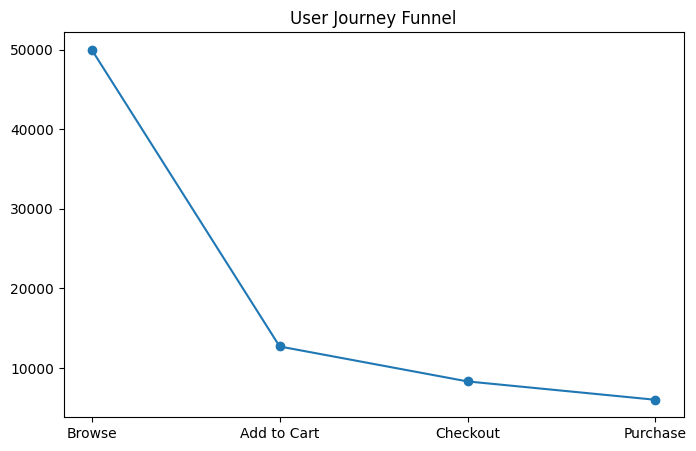

In [43]:
import matplotlib.pyplot as plt

stages = ['Browse','Add to Cart','Checkout','Purchase']
counts = [visitors, cart, checkout, purchase]

plt.figure(figsize=(8,5))
plt.plot(stages, counts, marker='o')
plt.title("User Journey Funnel")
plt.show()

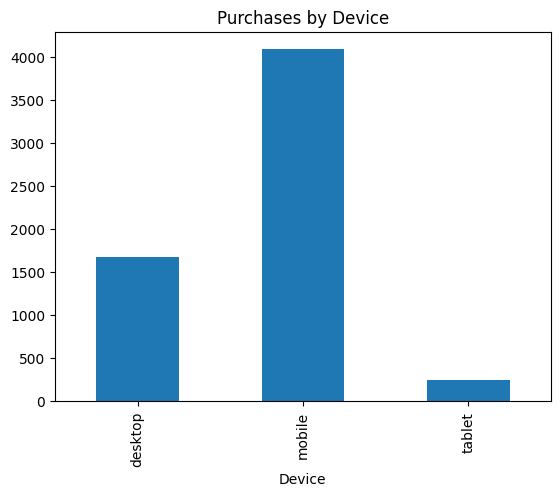

In [44]:
device_analysis.plot(kind='bar')
plt.title("Purchases by Device")
plt.show()

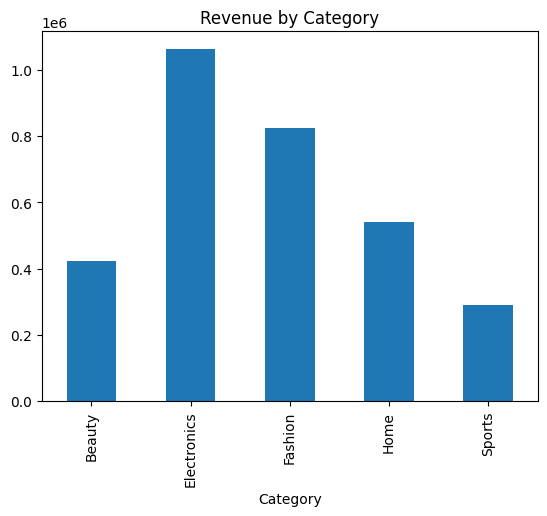

In [45]:
purchase_df.groupby('Category')['Revenue'].sum().plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

In [46]:
df['Time_Stamp'] = pd.to_datetime(df['Time_Stamp'])

In [47]:
df['Time_Stamp'].dtype

dtype('<M8[ns]')

In [48]:
df['Date']=df['Time_Stamp'].dt.date

In [49]:
df['time']=df['Time_Stamp'].dt.time

In [50]:
df['day']=df['Time_Stamp'].dt.day_name()

In [51]:
df['hour']=df['Time_Stamp'].dt.hour

In [52]:
df['week_no']=df['Time_Stamp'].dt.isocalendar().week

In [53]:
df.head()

,User_ID,Session_ID,Event,Time_Stamp,Device,Region,Channel,Category,Revenue,Bounce_back,Date,time,day,hour,week_no
0,USR00001,SES00001,Browse,2026-06-01 02:32:19,mobile,North,Organic Search,Fashion,NaN,False,2026-06-01,02:32:19,Monday,2,23
1,USR00001,SES00001,Add to Cart,2026-06-01 02:33:19,mobile,North,Organic Search,Fashion,NaN,False,2026-06-01,02:33:19,Monday,2,23
2,USR00001,SES00001,Checkout,2026-06-01 02:41:19,mobile,North,Organic Search,Fashion,NaN,False,2026-06-01,02:41:19,Monday,2,23
3,USR00001,SES00001,Purchase,2026-06-01 02:48:19,mobile,North,Organic Search,Fashion,128.53,False,2026-06-01,02:48:19,Monday,2,23
4,USR00002,SES00002,Browse,2026-06-01 08:34:26,desktop,North,Social Media,Home,NaN,True,2026-06-01,08:34:26,Monday,8,23


In [54]:
df.to_excel("user_journey_funnel_cleaned.xlsx", index=False)